# Task 10: K-means Clustering

Machine Learning Fundamentals

## Goal
Generate 100 two-dimensional points, fit three clusters, inspect centroids, and compute a silhouette score.

## Setup
Run all cells from top to bottom with Python 3. Required packages: numpy, pandas, matplotlib, scipy, scikit-learn, and IPython.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown

plt.rcParams.update({"figure.figsize": (7, 4), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 8)
pd.set_option("display.width", 88)
SEED = 42
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.9.0


## Data and method
Use synthetic uniform points in the unit square, matching the reference exercise type. The seed fixes the input. Both coordinates have the same scale. Three clusters are specified for the exercise; uniform random points do not imply three natural populations.

Input shape: (100, 2)


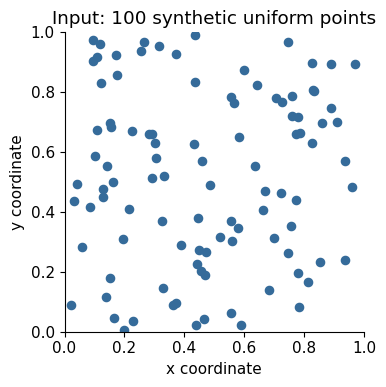

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

rng = np.random.default_rng(SEED)
points = rng.uniform(0, 1, size=(100, 2))
assert points.shape == (100, 2) and np.isfinite(points).all()
print("Input shape:", points.shape)
fig, ax = plt.subplots()
ax.scatter(points[:, 0], points[:, 1], color="#356b9a", s=35)
ax.set(xlabel="x coordinate", ylabel="y coordinate",
       title="Input: 100 synthetic uniform points", xlim=(0, 1), ylim=(0, 1))
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### Fit K-means
Twenty initializations reduce sensitivity to a poor starting set of centroids.

In [3]:
clustering = KMeans(n_clusters=3, n_init=20, random_state=SEED)
assignments = clustering.fit_predict(points)
centers = clustering.cluster_centers_
silhouette = silhouette_score(points, assignments)
print("Centroids:")
print(pd.DataFrame(centers, columns=["x", "y"]).round(4).to_string())
print("Labels in input-row order:")
print(assignments)
print("Cluster sizes:", np.bincount(assignments))
print(f"Inertia: {clustering.inertia_:.4f}")
print(f"Silhouette score: {silhouette:.4f}")
assert np.bincount(assignments).sum() == len(points)

Centroids:
        x       y
0  0.4777  0.2096
1  0.2159  0.6996
2  0.7684  0.7148
Labels in input-row order:
[2 2 1 2 1 1 2 0 0 2 0 2 0 0 1 2 0 0 1 1 1 0 2 0 0 0 2 2 1 0 2 2 2 0 1 1 0
 0 1 2 0 0 0 2 1 1 0 1 0 1 2 1 2 0 1 0 1 1 2 1 2 1 1 0 1 1 0 0 2 0 0 2 0 1
 0 2 1 1 1 2 1 0 0 2 1 1 1 0 1 2 2 0 2 0 0 0 1 0 2 0]
Cluster sizes: [38 34 28]
Inertia: 5.2361
Silhouette score: 0.4412


## Results
### Visualize assignments and centroids

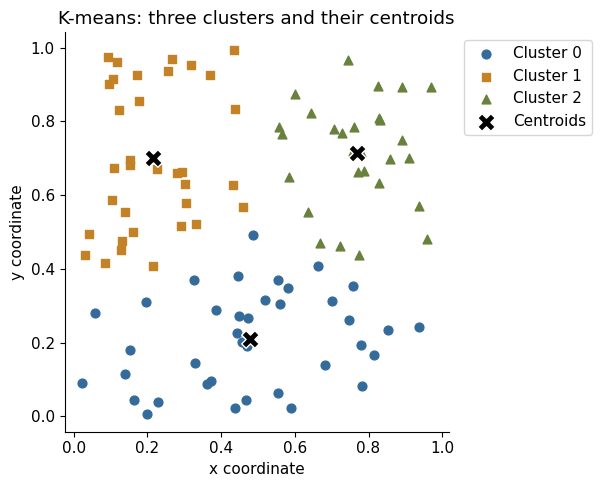

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
for cluster, color, marker in zip(range(3),
        ["#356b9a", "#c48227", "#68813c"], ["o", "s", "^"]):
    members = points[assignments == cluster]
    ax.scatter(members[:, 0], members[:, 1], color=color, marker=marker,
               s=40, label=f"Cluster {cluster}")
ax.scatter(centers[:, 0], centers[:, 1], marker="X", s=160,
           color="black", edgecolors="white", label="Centroids")
ax.set(xlabel="x coordinate", ylabel="y coordinate",
       title="K-means: three clusters and their centroids")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Takeaways

In [5]:
display(Markdown(
    f"K-means assigned all **{len(points)}** points to three clusters, "
    f"with silhouette score **{silhouette:.3f}**. Silhouette scores range "
    "from -1 to 1; larger values indicate more separated, compact groups. "
    "A positive score here does not prove naturally occurring clusters: "
    "K-means partitions even uniformly generated data."
))

K-means assigned all **100** points to three clusters, with silhouette score **0.441**. Silhouette scores range from -1 to 1; larger values indicate more separated, compact groups. A positive score here does not prove naturally occurring clusters: K-means partitions even uniformly generated data.

## Reference and reproducibility
Task scope reference: [Aishani's Task 10 notebook](https://github.com/aishani-dutta1397/Machine-Learning-Fundamentals-Work/blob/main/T10_KMeans.ipynb). The reference was consulted for the exercise scope; the code, explanations, validation, and presentation here were independently written. Outputs are generated by the cells above. Cluster numbers, where used, are arbitrary identifiers.